In [ ]:
# The step-by-step instructions to process S&P Global Capital IQ data and merge with Global Tracker
# 1. Download Mine Economic Cost Curve data from Capital IQ web
# 2. Retrieve Mine Property data via Capital IQ Excel Plug-in from "Screener" tab on the Capital IQ web, make a copy of the raw dataset to remove all default function in each cell that is used to retrieve data
# 3. Melt the copy capital IQ data based on Iron ore Fe content/cost, and keep effective data only which has Fe content/cost/emission/.....
# 4.Use property name and GPS location to match plants with those in Global Tracker dataset using LLM like CLoude (need manual inspection after Cloude matching), and join the matched Mine/Operator data to Mine Econ dataset along with Fe Content/cost/emission/product name/.....
# 5. Join the Mine Econ dataset (with cost/Fe content/emission/.....) to Global Tracker dataset

In [1]:
import pandas as pd

In [ ]:
# Output the raw capital IQdataframe to a new Excel file to remove the Excel functions from each cell
# We collected raw Capital IQ data via S&P Capital IQ Pro Excel Add-in, each cell has a default function that is used to retrieve the data, so need to transform the data to plain format before processing otherwise very slow

# iron_mines.to_excel('../data/S&PGlobal iron ore mine economics/iron_mines_data.xlsx', index=False)

In [6]:
def capital_iq_property_data_processing(data_path: str) -> pd.DataFrame:

    # Load data
    capital_iq_data = pd.read_excel(data_path, sheet_name='Sheet1', index_col=False)
    capital_iq_data['IRON_ORE_PRODUCTION_PELLET_TONNE'] = capital_iq_data['COMMODITY_PRODUCTION_TONNE_BY_PERIOD'] - (capital_iq_data['IRON_ORE_PRODUCTION_CONCENTRATE_TONNE'] + \
                                                                    capital_iq_data['IRON_ORE_PRODUCTION_LUMP_TONNE'] + capital_iq_data['IRON_ORE_PRODUCTION_FINES_TONNE'])
    # check if the new column has negative values, if so, change the negative values to 0
    capital_iq_data['IRON_ORE_PRODUCTION_PELLET_TONNE'] = capital_iq_data['IRON_ORE_PRODUCTION_PELLET_TONNE'].apply(lambda x: max(x, 0))

    # Put the new column after the column 'IRON_ORE_PRODUCTION_LUMP_TONNE'
    capital_iq_data.insert(capital_iq_data.columns.get_loc('IRON_ORE_PRODUCTION_LUMP_TONNE') + 1, 'IRON_ORE_PRODUCTION_PELLET_TONNE', capital_iq_data.pop('IRON_ORE_PRODUCTION_PELLET_TONNE'))

    # Filter the dataframe based on the column 'ACTV_STATUS' and change the status name from 'Active' to 'operating', 'Care And Maintenance' to 'mothballed', 'Rehabilitation' to 'mothballed', 'Temporarily On Hold' to 'proposed', 'On Hold Awaiting Higher Prices' to 'proposed', 'On Hold Awaiting Financing' to 'proposed',  'Under Litigation' to 'proposed'
    capital_iq_data = capital_iq_data[capital_iq_data['ACTV_STATUS'].isin(['Active', 'Care And Maintenance', 'Rehabilitation', 'Temporarily On Hold', 'On Hold Awaiting Higher Prices', 'On Hold Awaiting Financing', 'Under Litigation'])]
    capital_iq_data['ACTV_STATUS'] = capital_iq_data['ACTV_STATUS'].replace({'Active': 'operating', 'Care And Maintenance': 'mothballed', 'Rehabilitation': 'mothballed', 'Temporarily On Hold': 'proposed', 'On Hold Awaiting Higher Prices': 'proposed', 'On Hold Awaiting Financing': 'proposed',  'Under Litigation': 'proposed'})

    # ── Pivot product-level columns ───────────────────────────────────────────
    # Each product group maps its original column names to shared value_name labels.
    # product_name is the 3rd token (index 2) of the FE-content column name.
    PIVOT_GROUPS = {
        'CONCENTRATE': {
            'IRON_ORE_CONCENTRATE_FE_CONTENT_PCT':                                                       'fe_content_pct',
            'IRON_ORE_PRODUCTION_CONCENTRATE_TONNE':                                                     'production_tonne',
            'TOTAL_CASH_COST_DMT_CONCENTRATE':                                                           'total_cash_cost_dmt',
            'TOTAL_CASH_COST_CFR_DMT_CONCENTRATE':                                                       'total_cash_cost_cfr_dmt',
            'CONCENTRATE_BULKMETALS_SCOPE_1_2_TRANSPORTATION_EMISSIONS_PAID_METAL_PRODUCTION_EMISSIONS': 'scope_1_2_emissions',
        },
        'Fines': {
            'IRON_ORE_Fines_FE_CONTENT_PCT':                                                             'fe_content_pct',
            'IRON_ORE_PRODUCTION_FINES_TONNE':                                                           'production_tonne',
            'TOTAL_CASH_COST_DMT_FINES':                                                                 'total_cash_cost_dmt',
            'TOTAL_CASH_COST_CFR_DMT_FINES':                                                             'total_cash_cost_cfr_dmt',
            'FINES_BULKMETALS_SCOPE_1_2_TRANSPORTATION_EMISSIONS_PAID_METAL_PRODUCTION_EMISSIONS':       'scope_1_2_emissions',
        },
        'Lump': {
            'IRON_ORE_Lump_FE_CONTENT_PCT':                                                              'fe_content_pct',
            'IRON_ORE_PRODUCTION_LUMP_TONNE':                                                            'production_tonne',
            'TOTAL_CASH_COST_DMT_LUMP':                                                                  'total_cash_cost_dmt',
            'TOTAL_CASH_COST_CFR_DMT_LUMP':                                                              'total_cash_cost_cfr_dmt',
            'LUMP_BULKMETALS_SCOPE_1_2_TRANSPORTATION_EMISSIONS_PAID_METAL_PRODUCTION_EMISSIONS':        'scope_1_2_emissions',
        },
        'Pellet': {
            'IRON_ORE_Pellet_FE_CONTENT_PCT':                                                            'fe_content_pct',
            'IRON_ORE_PRODUCTION_PELLET_TONNE':                                                          'production_tonne',
            'TOTAL_CASH_COST_DMT_PELLET':                                                                'total_cash_cost_dmt',
            'TOTAL_CASH_COST_CFR_DMT_PELLET':                                                            'total_cash_cost_cfr_dmt',
            'PELLET_BULKMETALS_SCOPE_1_2_TRANSPORTATION_EMISSIONS_PAID_METAL_PRODUCTION_EMISSIONS':      'scope_1_2_emissions',
        },
    }

    all_pivot_cols = {c for group in PIVOT_GROUPS.values() for c in group}
    id_cols = [c for c in capital_iq_data.columns if c not in all_pivot_cols]

    product_frames = []
    for product_name, col_map in PIVOT_GROUPS.items():
        valid_map = {c: v for c, v in col_map.items() if c in capital_iq_data.columns}
        sub = capital_iq_data[id_cols + list(valid_map.keys())].copy()
        sub = sub.rename(columns=valid_map)
        sub['product_name'] = product_name
        product_frames.append(sub)

    melted = pd.concat(product_frames, ignore_index=True)

    # Keep only rows where FE content is present and non-zero
    melted = melted[
        melted['fe_content_pct'].notna() & (melted['fe_content_pct'] != 0)
    ].reset_index(drop=True)

    return melted

In [11]:
data_path = '../data/SPGlobalCaptialQ/'
df = capital_iq_property_data_processing(data_path + 'iron_ore_property.xlsx')
# df.to_excel(data_path + 'melted_capital_iq_data.xlsx', index=False)

In [ ]:
# # Capital IQ data exploration
# capital_iq_data = pd.read_excel(data_path + 'iron_ore_property.xlsx', sheet_name='Sheet1', index_col=False)
# capital_iq_data['IRON_ORE_PRODUCTION_PELLET_TONNE'] = capital_iq_data['COMMODITY_PRODUCTION_TONNE_BY_PERIOD'] - (capital_iq_data['IRON_ORE_PRODUCTION_CONCENTRATE_TONNE'] + \
#                                                                 capital_iq_data['IRON_ORE_PRODUCTION_LUMP_TONNE'] + capital_iq_data['IRON_ORE_PRODUCTION_FINES_TONNE'])
# # check if the new column has negative values, if so, change the negative values to 0
# capital_iq_data['IRON_ORE_PRODUCTION_PELLET_TONNE'] = capital_iq_data['IRON_ORE_PRODUCTION_PELLET_TONNE'].apply(lambda x: max(x, 0))

# # Put the new column after the column 'IRON_ORE_PRODUCTION_LUMP_TONNE'
# capital_iq_data.insert(capital_iq_data.columns.get_loc('IRON_ORE_PRODUCTION_LUMP_TONNE') + 1, 'IRON_ORE_PRODUCTION_PELLET_TONNE', capital_iq_data.pop('IRON_ORE_PRODUCTION_PELLET_TONNE'))

# # Filter the dataframe based on the column 'ACTV_STATUS' and change the status name from 'Active' to 'operating', 'Care And Maintenance' to 'mothballed', 'Rehabilitation' to 'mothballed', 'Temporarily On Hold' to 'proposed', 'On Hold Awaiting Higher Prices' to 'proposed', 'On Hold Awaiting Financing' to 'proposed',  'Under Litigation' to 'proposed'
# capital_iq_data = capital_iq_data[capital_iq_data['ACTV_STATUS'].isin(['Active', 'Care And Maintenance', 'Rehabilitation', 'Temporarily On Hold', 'On Hold Awaiting Higher Prices', 'On Hold Awaiting Financing', 'Under Litigation'])]
# capital_iq_data['ACTV_STATUS'] = capital_iq_data['ACTV_STATUS'].replace({'Active': 'operating', 'Care And Maintenance': 'mothballed', 'Rehabilitation': 'mothballed', 'Temporarily On Hold': 'proposed', 'On Hold Awaiting Higher Prices': 'proposed', 'On Hold Awaiting Financing': 'proposed',  'Under Litigation': 'proposed'})


# # count the number of rows in the column 'prop_name' where the total Fe content of all four product types is equal to 0
# capital_iq_data['total_cash_cost_dmt_sum'] = capital_iq_data[['TOTAL_CASH_COST_DMT_CONCENTRATE', 'TOTAL_CASH_COST_DMT_FINES', 'TOTAL_CASH_COST_DMT_LUMP', 'TOTAL_CASH_COST_DMT_PELLET']].sum(axis=1)
# zero_cash_cost_count = capital_iq_data[capital_iq_data['total_cash_cost_dmt_sum'] == 0]['PROP_NAME'].nunique()
# print(f'Number of unique properties with zero total cash cost dmt: {zero_cash_cost_count}')

Number of unique properties with zero total cash cost dmt: 716


In [ ]:
# df2 = pd.read_excel(data_path + 'melted_capital_iq_data.xlsx', sheet_name='Sheet1', index_col=False)
# # count the number of rows in the column 'prop_name'
# unique_properties_count = df2['PROP_NAME'].nunique()
# print(f'Number of unique properties: {unique_properties_count}')


Number of unique properties: 233


In [46]:
# Get location data from capital IQ (iron_ore_property.xlsx) and merge it with the mine asset matches data (mine_asset_matches_distance.xlsx) to get the lat and long of each mine asset match, save the merged data to a new Excel file

def get_location_from_property_data(data1, data2):
    iron_ore_property = pd.read_excel(data1, sheet_name='Sheet1', index_col=False)
    mine_asset_matches = pd.read_excel(data2, sheet_name='Sheet2', index_col=False)

    # Left join iron_ore_propery to mine_asset_matches on the column 'PROP_NAME' on iron_ore_propery and Mine Short Name (List 2) on mine_asset_matches, get the lat and long from iron_ore_property
    merged_df = pd.merge(mine_asset_matches, iron_ore_property[['PROP_NAME', 'LATITUDE', 'LONGITUDE', 'STATE_PROVINCE', 'COUNTRY_NAME']], how='left', left_on='Mine Short Name (List 2)', right_on='PROP_NAME')
    merged_df.drop(columns=['PROP_NAME'], inplace=True)
    # save to the sheet2 of mine_asset_matches_final.xlsx
    merged_df.to_excel('../data/SPGlobalCaptialQ/S&PGlobal iron ore mine economics/mine_asset_matches_distance.xlsx', sheet_name='Sheet2', index=False)
    return merged_df


data1 = '../data/SPGlobalCaptialQ/iron_ore_property.xlsx'
data2 = '../data/SPGlobalCaptialQ/S&PGlobal iron ore mine economics/mine_asset_matches_distance.xlsx'
df = get_location_from_property_data(data1, data2)




In [ ]:
# # left join melted_capital_iq_data to  mine_distance_matches (mines with cost data) on prop_name, and add only product_name to the mine_distance_matches dataframe, then join based on both prop_name and product name, save the merged data to a new Excel file  
# def merge_product_name_emisions_to_mine_distance_matches(data1, data2):
#     melted_capital_iq_data = pd.read_excel(data1, sheet_name='Sheet1', index_col=False)
#     mine_distance_matches = pd.read_excel(data2, sheet_name='Distance Match Results', index_col=False)

#     # Left join melted_capital_iq_data to mine_distance_matches on prop_name, get the product_name and emissions from melted_capital_iq_data
#     merged_df = pd.merge(mine_distance_matches, melted_capital_iq_data[['PROP_NAME', 'product_name', 'scope_1_2_emissions']], how='left', left_on=['capital_iq_mines'], right_on=['PROP_NAME'])
#     merged_df.drop(columns=['PROP_NAME'], inplace=True)

#     return merged_df

# # join the merged_df to SPGlobal_MineEconomics_22-Apr-2026.xlsx on the column capital_iq_mines on right and Property Name on left, and get the global_tracker_mines, global_tracker_Operator, capital_iq_State/Province,product_name, emissions from merged_df, save the final merged data to a new Excel file
# def merge_with_mine_econ(merged_df,data3):
#     mine_econ = pd.read_excel(data3, sheet_name='Data', index_col=False, skiprows=12)
#     final_merged_df = pd.merge(mine_econ, merged_df[['capital_iq_mines', 'product_name', 'scope_1_2_emissions', 'capital_iq_State/Province', 'global_tracker_mines', 'global_tracker_Operator']], how='left', left_on='Property', right_on='capital_iq_mines')
#     final_merged_df.drop(columns=['capital_iq_mines'], inplace=True)
#     # merge the correct_mine column with global_tracker_mines and correct_operator with global_tracker_Operator, if the global_tracker_mines column is not null, then use the value in global_tracker_mines column to fill the correct_mine column, if the global_tracker_Operator column is not null, then use the value in global_tracker_Operator column to fill the correct_operator column
    
#     final_merged_df['Correct_mine'] = final_merged_df.apply(lambda x: x['global_tracker_mines'] if pd.notnull(x['global_tracker_mines']) else x['Correct_mine'], axis=1)
#     final_merged_df['Correct_operator'] = final_merged_df.apply(lambda x: x['global_tracker_Operator'] if pd.notnull(x['global_tracker_Operator']) else x['Correct_operator'], axis=1)
#     final_merged_df.drop(columns=['global_tracker_mines', 'global_tracker_Operator'], inplace=True)

#     return final_merged_df

# data1 = '../data/SPGlobalCaptialQ/melted_capital_iq_data.xlsx'
# data2 = '../data/SPGlobalCaptialQ/mine_distance_matches (mines with cost data).xlsx'
# data3 = '../data/SPGlobalCaptialQ/S&PGlobal iron ore mine economics/SPGlobal_MineEconomics_22-Apr-2026.xlsx'
# df = merge_product_name_emisions_to_mine_distance_matches(data1, data2)

# final_df = merge_with_mine_econ(df, data3)

# final_df.to_excel('../data/SPGlobalCaptialQ/S&PGlobal iron ore mine economics/final_merged_data.xlsx', index=False)

In [ ]:
# Join melted Capital IQ data to MineEcon dataframe
def mineEcon_mineProperty_merge(data1, data2, data3):
    df1 = pd.read_excel(data1, sheet_name='Sheet1', index_col=False)
    df1['product_name'] = df1['product_name'].str.title()
    df2 = pd.read_excel(data2, sheet_name='Data', index_col=False, skiprows=12)
    df3 = pd.read_excel(data3,  sheet_name='Distance Match Results', index_col=False)
    df2 = df2.iloc[1:]
    df2 = df2.iloc[:-2]
    df2['product name'] = df2['Product'].str.split(' ').str[-1]
    print('The number of unique of mine plants in MineEcon dataset with non-blank mine/operator is: ', df2[~df2['Correct_mine'].isna()]['Correct_mine'].nunique())
    
    merged_df = pd.merge(df2,df1[['PROP_NAME', 'product_name', 'STATE_PROVINCE', 'scope_1_2_emissions']], how='left', left_on=['Property', 'product name'], right_on = ['PROP_NAME','product_name'])
    merged_df.drop(columns=['PROP_NAME', 'product_name'], inplace=True)
    df3 = df3[df3['note'].isna()]
    print('The number of unique of mine plants in MineEcon dataset matched using distance is: ', df3['capital_iq_mines'].nunique())

    merged_df_2 = pd.merge(merged_df, df3[['capital_iq_mines', 'global_tracker_mines', 'global_tracker_Operator']], how='left', left_on='Property', right_on='capital_iq_mines')
    merged_df_2.drop(columns=['capital_iq_mines'], inplace=True)
    merged_df_2 = merged_df_2.drop_duplicates()
    merged_df_2['Correct_operator'] = merged_df_2['Correct_operator'].combine_first(merged_df_2['global_tracker_Operator'])
    merged_df_2['Correct_mine'] = merged_df_2['Correct_mine'].combine_first(merged_df_2['global_tracker_mines'])
    merged_df_2.drop(columns=['global_tracker_mines', 'global_tracker_Operator'], inplace=True)
    merged_df_2 = merged_df_2.drop_duplicates()
    print('The number of unique of mine plants in merged MineEcon dataset with non-blank Econ data is: ', merged_df_2[~merged_df_2['Correct_mine'].isna()]['Correct_mine'].nunique())
    return merged_df_2


def mineEcon_globalTracker_merge(df1, data_path):
    globaltracker_data = pd.read_excel(data_path, sheet_name='Sheet1', index_col=False)
    final_df =  globaltracker_data.merge(df1, left_on=['Asset name (English)', 'Operator'], right_on=['Correct_mine', 'Correct_operator'], how='left').\
        drop(columns=['Product', 'Property','Property ID', 'Country/Region', ' Equity Owner(s) (Ownership %)', 'Moisture (%)', ' Percent Lower (%)', ' Seaborne Shipment ($/dmt)', 'Correct_mine', 'Correct_operator', 'STATE_PROVINCE'])
    final_df = final_df.drop_duplicates() 

    return final_df


melted_capitalIQ_path = '..\data\SPGlobalCaptialQ\melted_capital_iq_data.xlsx'
mine_econ_path = '..\data\SPGlobalCaptialQ\S&PGlobal iron ore mine economics\SPGlobal_MineEconomics_22-Apr-2026.xlsx'
mine_distanct_match = '..\data\SPGlobalCaptialQ\mine_asset_matches_w_distance.xlsx'
globaltracker = '..\data\Processed_data\Iron_mines_data_w_cost.xlsx'
mine_econ_data = mineEcon_mineProperty_merge(melted_capitalIQ_path, mine_econ_path, mine_distanct_match)
final_df = mineEcon_globalTracker_merge(mine_econ_data, globaltracker)
final_df.to_excel('..\data\Processed_data\iron_mine_w_cost_FeContent1.xlsx')
# final_df.head()

The number of unique of mine plants in MineEcon dataset with non-blank mine/operator is:  123
The number of unique of mine plants in MineEcon dataset matched using distance is:  29
The number of unique of mine plants in merged MineEcon dataset with non-blank Econ data is:  144


In [5]:
print('The number of unique of mine plants in MineEcon dataset is: ', mine_econ_data['Property'].nunique())
print('The number of unique of mine plants in GlobalTracker dataset is: ', final_df['Asset name (English)'].nunique())
print('The number of unique of mine plants in merged MineEcon dataset with non-blank Econ data is: ', mine_econ_data[~mine_econ_data['Correct_mine'].isna()]['Correct_mine'].nunique())
print('The number of unique of mine plants in GlobalTracker dataset with non-blank Econ data is: ', final_df[~final_df['Correct_mine'].isna()]['Asset name (English)'].nunique())

# Distance-based matching increase matched mines from 122 to 144

The number of unique of mine plants in MineEcon dataset is:  243
The number of unique of mine plants in GlobalTracker dataset is:  917
The number of unique of mine plants in merged MineEcon dataset with non-blank Econ data is:  144
The number of unique of mine plants in GlobalTracker dataset with non-blank Econ data is:  144


In [ ]:
# the capacity of the mines with Fe content data divided by total capacit of all mines
# change capacity data type to numeric, remove comma in the capacity data and convert to float, convert unknown as 0   
final_df['Capacity_2025'] = final_df['Capacity_2025'].astype(str).replace({',': '', 'unknown': '0'}, regex=True).astype(float)
# remove those with 0 capacity data
final_df = final_df[final_df['Capacity_2025'] != 0]
capacity_with_fe_content = final_df[~final_df['Fe Content (%)'].isna()]['Capacity_2025'].sum()
total_capacity = final_df['Capacity_2025'].sum()
print('The percentage of global iron ore mine capacity in 2025 with Fe content data is: ', capacity_with_fe_content/total_capacity)

# The globaltracker and capitalIQ merged dataset has 144 mines (15.7%) with 58% capacity

The percentage of global iron ore mine capacity in 2025 with Fe content data is:  0.5806811910785414


In [ ]:
# Retrieve those not matched between capital IQ and global tracker
mineEcon = pd.read_excel(mine_econ_path, sheet_name='Data', index_col=False, skiprows=12)
mineEcon = mineEcon.iloc[1:]
mineEcon = mineEcon.iloc[:-2]
mineEcon = mineEcon[mineEcon['Correct_mine'].isna()]['Property']
# Filter the mine property data with blank mine name 
mine_property = pd.read_excel(melted_capitalIQ_path, sheet_name='Sheet1', index_col=False)
# mine_property = mine_property[mine_property['ACTV_STATUS'].isin(['Active', 'Care And Maintenance', 'Rehabilitation', 'Temporarily On Hold', 'On Hold Awaiting Higher Prices', 'On Hold Awaiting Financing', 'Under Litigation'])]  
mine_property = mine_property[mine_property['PROP_NAME'].isin(mineEcon)]
mine_property = mine_property[['PROP_NAME', 'OPERATOR_NAME', 'LATITUDE', 'LONGITUDE', 'STATE_PROVINCE', 'COUNTRY_NAME']]
mine_property.to_excel('../data/SPGlobalCaptialQ/mine_property_not_matched.xlsx', index=False)
# upload mine_property_not_matched.xlsx to chatgpt, doubao to get city, mine name, and operator information, and download the proccessed data from those GPT models for the next step

In [76]:
# Merge the mine property data with the mine econ data to get Fe content, cost, emission
# The properties here are those not matched successfully with Global Tracker based on name and distance matching
properties = pd.read_excel('../data/SPGlobalCaptialQ/铁矿名称及运营商信息完整表_ChatGPT修订版.xlsx', sheet_name='铁矿完整信息表', index_col=False)
mineEcon = pd.read_excel(mine_econ_path, sheet_name='Data', index_col=False, skiprows=12)
mineEcon = mineEcon.iloc[1:]
mineEcon = mineEcon.iloc[:-2]
mine_property = pd.read_excel('../data/SPGlobalCaptialQ/melted_capital_iq_data.xlsx', sheet_name='Sheet1', index_col=False)
mine_property['product_name'] = mine_property['product_name'].str.title()
property_joined_list = ['PROP_NAME', 'product_name', 'scope_1_2_emissions', 'ACTV_STATUS', 'OPERATOR_NAME','OWNER_LIST', \
                        'OWNER_NAME_1', 'OWNER1_PCT', 'OWNER1_HQ', 'OWNER1_CITY_STATE', 'OWNER1_LOCATION', 'OWNER1_FRGN_PROVINCE', 'OWNER1_COUNTRY', \
                        'OWNER2_NAME', 'OWNER2_PCT', 'OWNER2_HQ', 'OWNER2_CITY_STATE', 'OWNER2_LOCATION', 'OWNER2_FRGN_PROVINCE', 'OWNER2_COUNTRY', \
                        'OWNER3_NAME', 'OWNER3_PCT', 'OWNER3_HQ', 'OWNER3_CITY_STATE', 'OWNER3_LOCATION', 'OWNER3_FRGN_PROVINCE', 'OWNER3_COUNTRY', \
                        'OWNER4_NAME', 'OWNER4_PCT', 'OWNER4_HQ', 'OWNER4_CITY_STATE', 'OWNER4_LOCATION', 'OWNER4_FRGN_PROVINCE', 'OWNER4_COUNTRY', \
                        'OWNER5_NAME', 'OWNER5_PCT', 'OWNER5_HQ','OWNER5_CITY_STATE', 'OWNER5_LOCATION', 'OWNER5_FRGN_PROVINCE', 'OWNER5_COUNTRY', \
                        'PRODUCTION_CAPACITY_TONNE', 'RESV_ORE_TONNAGE'
]
mine_joined = pd.merge(mineEcon, mine_property[property_joined_list], how='left', left_on=['Property', 'product_type'], right_on=['PROP_NAME', 'product_name'])
mine_joined.drop(columns=['PROP_NAME', 'product_name'], inplace=True)

# left join mineEcon to properties on the column "PROP_NAME"
merged_data = pd.merge(properties, mine_joined, how='left', left_on=['PROP_NAME'], right_on='Property')
drop_list = ['Product',	'Property',	'Property ID','Country/Region',' Equity Owner(s) (Ownership %)','Moisture (%)',' Percent Lower (%)', 'Correct_operator','Correct_mine']
merged_data.drop(columns=drop_list, inplace=True)
merged_data = merged_data.drop_duplicates()
# merged_data = pd.merge(merged_data, mine_joined, how='left', left_on=['PROP_NAME','product_type'], right_on=['Property', 'product_type'])
# merged_data.drop(columns=drop_list, inplace=True)
# merged_data = merged_data.drop_duplicates()
merged_data.to_excel('../data/SPGlobalCaptialQ/distance_name_unmatched_merge_w_mineEcon1.xlsx', index=False)

In [6]:
gt_df = pd.read_excel('../data/Processed_data/globaltracker_w_cost_FeContent.xlsx', sheet_name='Sheet1', index_col=False)
# find if Fe Content column is blank, other columns like production,, FOB cost, product type, emissions, CFR cost are also blank
# count the number of rows where Fe Content is blank but production is not blank, FOB cost is not blank, product type is not blank, emissions is not blank, CFR cost is not blank
fe_content_blank = gt_df[gt_df['Fe Content (%)'].isna()]
fe_content_blank_production_not_blank = fe_content_blank[fe_content_blank['Production (M dry metric tonnes) '].notna()]
fe_content_blank_fob_cost_not_blank = fe_content_blank_production_not_blank[fe_content_blank_production_not_blank[' Total Cash Cost (FOB) ($/dmt)'].notna()]
fe_content_blank_product_type_not_blank = fe_content_blank_fob_cost_not_blank[fe_content_blank_fob_cost_not_blank['product_type'].notna()]
fe_content_blank_emissions_not_blank = fe_content_blank_product_type_not_blank[fe_content_blank_product_type_not_blank['scope_1_2_emissions'].notna()]
fe_content_blank_cfr_cost_not_blank = fe_content_blank_emissions_not_blank[fe_content_blank_emissions_not_blank[' Total Cash Cost (CFR) ($/dmt)'].notna()]
count = fe_content_blank_cfr_cost_not_blank.shape[0]
print('The number of rows where Fe Content is blank but production, FOB cost, product type, emissions, CFR cost are not blank is: ', count) 

# Get the rows where Fe Content is blank
fe_content_blank_rows = gt_df[gt_df['Fe Content (%)'].isna()]
# save the fe_content_blank_rows to a new Excel file
fe_content_blank_rows.to_excel('../data/Processed_data/Fe_content_blank_rows.xlsx', index=False)

The number of rows where Fe Content is blank but production, FOB cost, product type, emissions, CFR cost are not blank is:  0


993


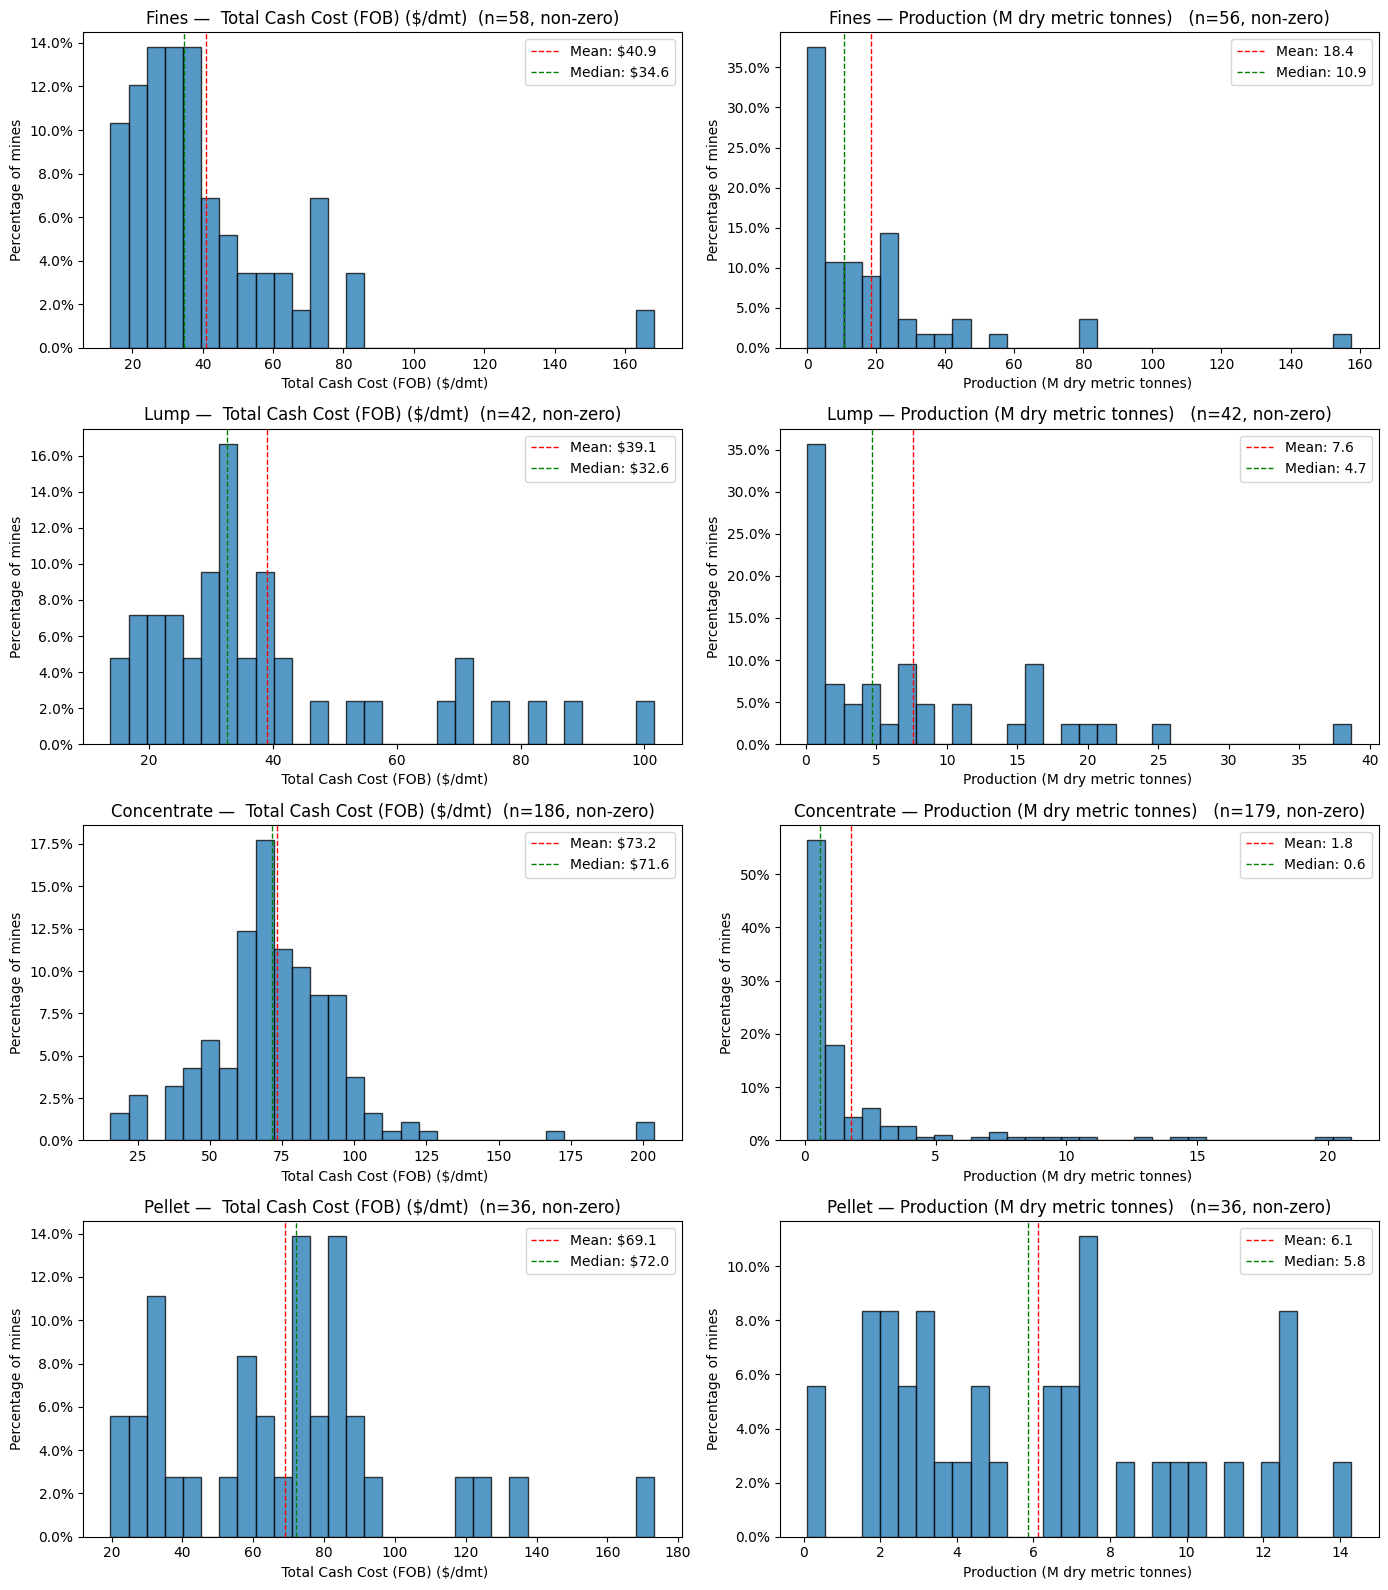

In [ ]:
# This section used to visualize iron ore mine results
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

iron_df = pd.read_excel('../data/Processed_Data/iron_mine_w_cost_FeContent.xlsx', sheet_name='Sheet1')
print(iron_df['Asset name (English)'].nunique())
mask = (iron_df['Capacity_2025'] != 'unknown') & (iron_df['Capacity_2025'] != '')
pd.to_numeric(iron_df.loc[mask, 'Capacity_2025'], errors='coerce').sum()


def plot_histograms(df, product_types, metrics, drop_zero=True):
    n_rows = len(product_types)
    n_cols = len(metrics)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(7 * n_cols, 4 * n_rows))
    # Ensure axes is always 2D for consistent indexing
    axes = np.atleast_2d(axes).reshape(n_rows, n_cols)

    for i, prod_type in enumerate(product_types):
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            data = pd.to_numeric(
                df.loc[df['product_type'] == prod_type, metric],
                errors='coerce'
            ).dropna()

            # Use only non-zero data points
            if drop_zero:
                data = data[data != 0]

            if data.empty:
                ax.set_title(f'{prod_type} — {metric}\n(no non-zero data)')
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, color='gray')
                continue

            # Dollar prefix only for cost metrics
            prefix = '$' if '$' in metric or 'Cost' in metric else ''

            # Weight each observation so bar heights sum to 100%
            weights = np.ones(len(data)) / len(data) * 100
            ax.hist(data, bins=30, weights=weights,
                    edgecolor='black', alpha=0.75)
            ax.yaxis.set_major_formatter(PercentFormatter())

            ax.set_xlabel(metric)
            ax.set_ylabel('Percentage of mines')
            ax.set_title(f'{prod_type} — {metric}  (n={len(data)}, non-zero)')
            ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1,
                       label=f'Mean: {prefix}{data.mean():.1f}')
            ax.axvline(data.median(), color='green', linestyle='--', linewidth=1,
                       label=f'Median: {prefix}{data.median():.1f}')
            ax.legend()

    fig.tight_layout()
    plt.show()


product_types = ['Fines', 'Lump', 'Concentrate', 'Pellet']
metrics = [' Total Cash Cost (FOB) ($/dmt)', 'Production (M dry metric tonnes) ']

plot_histograms(iron_df, product_types, metrics)
